In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.98'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
import matplotlib
import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
import gc
# Palatino
# pl.rc('font', family='DejaVu Sans')
import ast
import yaml




/tmp/ipykernel_409681/3209013679.py:12: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# nside = int(ast.literal_eval(sys.argv[1]))
nside = 1024
print('nside: ', nside)
# jdevice = int(ast.literal_eval(sys.argv[2]))
jdevice = 0
print('jdevice: ', jdevice)
# Ndevices = int(ast.literal_eval(sys.argv[3]))
Ndevices = 8
print('Ndevices: ', Ndevices)
# nside = 2048


nside:  1024
jdevice:  0
Ndevices:  8


In [5]:
import asdf


In [22]:
# def loadAllHalos(halodir,zID,mMin=None):
data_dir = '/mnt/ceph/users/backlight/AbacusBacklight_base_c0000_ph000'
# zval = 2.149
zval = 0.019
# zval = 1.009
with asdf.open(f'{data_dir}/lightcone_halos/z{zval}/lightcone_halo_info_000.asdf') as af:
    header = af['header']
    pos       = af['halo_lightcone']['InterpolatedPosition'][:]
    comovDis  = af['halo_lightcone']['InterpolatedComovingDist'][:]
    mass      = af['halo_lightcone']['InterpolatedN'][:]*header['ParticleMassMsun']
    vel       = af['halo_lightcone']['InterpolatedVelocity'][:]

# vec=np.stack([X,Y,Z])
#pos = np.array(vec.T)
r = np.sum(pos**2,axis=-1)**.5
r2d = np.sqrt(np.sum(pos[:,:2]**2,axis=-1))
#zs = chi2z(r)
#a_s = 1./(1+zs)
RAS=np.arccos(pos[:,0].astype('float64')/r2d.astype('float64'))
#RAS = np.arccos(pos[:,0]/r2d)
RAS[pos[:,1]<0] *=-1. # correctly assign negative y values
vec = (pos/r.reshape([-1,1]))
DECS = np.arcsin(vec[:,2])

vlos = np.sum(vel*vec,axis=-1)/(299792) # v is km/s. Convert to v/c



In [ ]:
# len(comovDis)
# len(np.where(mass > 10**12.0)[0])



73578

In [8]:
import re
data_dir = '/mnt/ceph/users/backlight/AbacusBacklight_base_c0000_ph000/lightcone_halos'
# list all the files in this directory:
files = [f for f in os.listdir(data_dir)]

# Extract the floating-point numbers from the file names
numbers = [re.findall(r'\d+\.\d+', f) for f in files]

# Flatten the list of lists and convert to a NumPy array
numbers = np.array([item for sublist in numbers for item in sublist], dtype=float)
numbers = np.sort(numbers)
print(numbers)




[0.    0.019 0.039 0.059 0.08  0.102 0.124 0.147 0.171 0.196 0.222 0.248
 0.276 0.304 0.334 0.365 0.397 0.431 0.466 0.503 0.542 0.582 0.625 0.671
 0.718 0.769 0.823 0.881 0.943 1.009 1.081 1.158 1.242 1.334 1.435 1.546
 1.67  1.81  1.968 2.149 2.359 2.606 2.903 3.269 3.731 4.341 5.193]


In [18]:
# files
# os.listdir(data_dir)
# len()

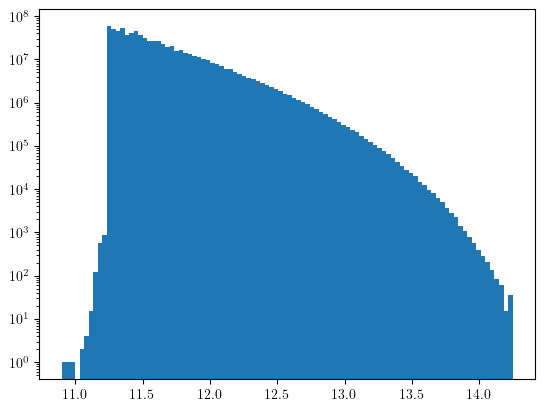

In [15]:
pl.figure()
_ = pl.hist(np.log10(mass), bins=100)
pl.yscale('log')
# pl.xlim(11.5, 15.0)




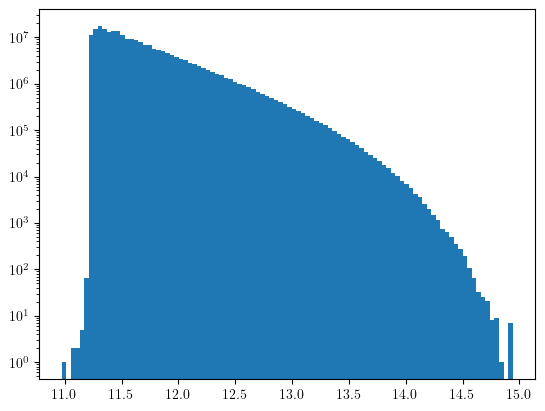

In [11]:
pl.figure()
_ = pl.hist(np.log10(mass), bins=100)
pl.yscale('log')
# pl.xlim(11.5, 15.0)



In [17]:
comovDis


NameError: name 'comovDis' is not defined

In [ ]:
# zs= chi2zi(comovDis)
nEls = mass.shape[0]
ras = np.array(RAS, dtype=np.float64)
decs = np.array(DECS, dtype=np.float64)
zs =jl.convert(jl.Array[jl.Float64, 1],zs)
m200c =jl.convert(jl.Array[jl.Float64, 1],mass)




In [3]:
ldir_base = '/mnt/ceph/users/backlight/AbacusBacklight_base_c0000_ph000/lightcone_halos/'
zmin = 0.01
zmax = 2
# get the list all directories in the base directory
dirs = [d for d in os.listdir(ldir_base) if os.path.isdir(os.path.join(ldir_base, d)) and d.startswith('z')]
# extract the redshift from the directory name which is float without the 'z' prefix:
redshifts = np.array([float(d[1:]) for d in dirs if d.startswith('z')])
# sort the directories and redshifts
sorted_indices = np.argsort(redshifts)
dirs = [dirs[i] for i in sorted_indices]
redshifts = redshifts[sorted_indices]
indsel = np.where((redshifts >= zmin) & (redshifts <= zmax))[0]
redshifts = redshifts[indsel]
dirs = [dirs[i] for i in indsel]

print(dirs)


['z0.019', 'z0.039', 'z0.059', 'z0.080', 'z0.102', 'z0.124', 'z0.147', 'z0.171', 'z0.196', 'z0.222', 'z0.248', 'z0.276', 'z0.304', 'z0.334', 'z0.365', 'z0.397', 'z0.431', 'z0.466', 'z0.503', 'z0.542', 'z0.582', 'z0.625', 'z0.671', 'z0.718', 'z0.769', 'z0.823', 'z0.881', 'z0.943', 'z1.009', 'z1.081', 'z1.158', 'z1.242', 'z1.334', 'z1.435', 'z1.546', 'z1.670', 'z1.810', 'z1.968']


In [5]:
# fname
len(dirs)



38

In [ ]:
%load_ext autoreload
%autoreload 2

import sys, os
# os.environ['PATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'+ os.environ['PATH']
# os.environ['PYTHONPATH']='/projects/bdne/spandey3/tex/texlive/bin/x86_64-linux:'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.98'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
import matplotlib
import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
import gc
# Palatino
# pl.rc('font', family='DejaVu Sans')
import ast
import yaml

import interpax
import asdf
import re
# nside = int(ast.literal_eval(sys.argv[1]))
# print('nside: ', nside)
# jdevice = int(ast.literal_eval(sys.argv[2]))
# print('jdevice: ', jdevice)
# Ndevices = int(ast.literal_eval(sys.argv[3]))
# print('Ndevices: ', Ndevices)
nside = 1024
jdevice = 0
Ndevices = 4

def split_array_power_ratio(arr, num_parts, power_val=0.5):
    n_total = arr.shape[0]
    j_values = np.arange(1, num_parts + 1)
    sqrt_j = j_values**power_val
    sum_of_sqrts = np.sum(sqrt_j)
    ideal_s1 = n_total / sum_of_sqrts
    ideal_sizes = ideal_s1 * sqrt_j
    int_sizes = np.floor(ideal_sizes).astype(int)
    remainder = n_total - np.sum(int_sizes)
    fractional_parts = ideal_sizes - int_sizes
    indices_to_increment = np.argsort(fractional_parts)[-remainder:]
    int_sizes[indices_to_increment] += 1
    split_indices = np.cumsum(int_sizes)[:-1]
    return np.split(arr, split_indices)


def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

yaml_file_path = '/mnt/home/spandey/ceph/GODMAX/param_files/params_default.yaml'
data = read_yaml(yaml_file_path)
sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(data)

halo_params_dict['rmin'] = 0.0001
halo_params_dict['rmax'] = 10.0
halo_params_dict['nr'] = 126
halo_params_dict['zmin'] = 0.01
halo_params_dict['zmax'] = 4.1
halo_params_dict['nz'] = 127
halo_params_dict['lg10_Mmin'] = 12.0
halo_params_dict['lg10_Mmax'] = 16.0
halo_params_dict['nM'] = 128

from godmax.get_B12_profile import Battaglia_12_16
import helpers.constants as constants
# cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 69.0, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8':0.81 ,'ns': 0.965}
cosmo_params_dict = {'w0':-1.0 ,'flat': True, 'H0': 67.74, 'Om0': 0.3089, 'Ob0': 0.0486, 'sigma8':0.8159 ,'ns': 0.9667}
# B12_test = Battaglia_12_16({'cosmo':cosmo_params_dict, 'init_power':False}, halo_params_dict)


B12_test = Battaglia_12_16(sim_params_dict={'cosmo':cosmo_params_dict, 'init_power':True}, halo_params_dict=halo_params_dict)


# chi2z_interp = interpax.Interpolator1D(np.log(B12_test.chi_array), B12_test.z_array, extrap=True)
# import scipy.interpolate as interp1d
from scipy import interpolate
chi2z_interp = interpolate.interp1d(np.log(B12_test.chi_array), B12_test.z_array, fill_value="extrapolate")



from astropy.io import fits
import h5py as h5
import healpy as hp

data_dir = '/mnt/ceph/users/backlight/AbacusBacklight_base_c0000_ph000/lightcone_halos'
files = [f for f in os.listdir(data_dir)]
zlist = [re.findall(r'\d+\.\d+', f) for f in files]
zlist = np.array([item for sublist in zlist for item in sublist], dtype=float)
zlist = np.sort(zlist)

# zmin_top = 0.075
# zmax_top = 0.2

zmin_top = 1.5
zmax_top = 2.0

indsel = np.where((zlist > zmin_top) & (zlist < zmax_top))[0]

zlist = zlist[indsel]
for zval in zlist:
    with asdf.open(f'{data_dir}/z{zval:.3f}/lightcone_halo_info_000.asdf') as af:
        header = af['header']
        pos       = af['halo_lightcone']['InterpolatedPosition'][:]
        comovDis  = af['halo_lightcone']['InterpolatedComovingDist'][:]
        mass      = af['halo_lightcone']['InterpolatedN'][:]*header['ParticleMassMsun']
        vel       = af['halo_lightcone']['InterpolatedVelocity'][:]

    # vec=np.stack([X,Y,Z])
    #pos = np.array(vec.T)
    r = np.sum(pos**2,axis=-1)**.5
    r2d = np.sqrt(np.sum(pos[:,:2]**2,axis=-1))
    #zs = chi2z(r)
    #a_s = 1./(1+zs)
    RAS=np.arccos(pos[:,0].astype('float64')/r2d.astype('float64'))
    #RAS = np.arccos(pos[:,0]/r2d)
    RAS[pos[:,1]<0] *=-1. # correctly assign negative y values
    vec = (pos/r.reshape([-1,1]))
    DECS = np.arcsin(vec[:,2])

    vlos_all = np.sum(vel*vec,axis=-1)/(299792) # v is km/s. Convert to v/c

    z_all = chi2z_interp(np.log(comovDis))
    ra_all = np.array(RAS, dtype=np.float64) * 180/np.pi
    dec_all = np.array(DECS, dtype=np.float64) * 180/np.pi

    M200c_all = mass
    indsel = np.where((M200c_all<4e15) & (M200c_all>(10**12.5)))[0]
    ra_all = ra_all[indsel]
    dec_all = dec_all[indsel]
    z_all = z_all[indsel]
    M200c_all = M200c_all[indsel]
    # M200m_all = M200m_all[indsel]
    vlos_all = vlos_all[indsel]
    print('total number of halos: ', len(M200c_all))

    argsort = np.flip(np.argsort(M200c_all))
    Nsel = (len(argsort)//Ndevices)*Ndevices
    argsort = argsort[:Nsel]
    Ngal_per_device = Nsel//Ndevices
    # argsort_here = argsort[jdevice*Ngal_per_device:(jdevice+1)*Ngal_per_device]
    argsort_split = split_array_power_ratio(argsort, Ndevices)
    argsort_here = argsort_split[jdevice]

    ra_all = ra_all[argsort_here]
    dec_all = dec_all[argsort_here]
    z_all = z_all[argsort_here]
    M200c_all = M200c_all[argsort_here]
    vlos_all = vlos_all[argsort_here]

    print('number of halos: ', len(M200c_all), ', mean log(M200c)', np.mean(np.log10(M200c_all)), ', mean z', np.mean(z_all))
    print('log10Mmin: ', np.min(np.log10(M200c_all)), ', log10Mmax: ', np.max(np.log10(M200c_all)))
    print('zmin: ', np.min(z_all), ', zmax: ', np.max(z_all))
    print('ra min: ', np.min(ra_all), ', ra max: ', np.max(ra_all))
    print('dec min: ', np.min(dec_all), ', dec max: ', np.max(dec_all))


    import warnings

    # Suppress all warnings
    warnings.filterwarnings("ignore")



    import pickle as pk
    import jax
    import scipy.interpolate as interp
    import healpy as hp
    import numpy as np
    from multiprocessing import Pool, cpu_count
    from astropy.io import fits
    # import constants
    import jax_cosmo.background as bkgrd
    from godmax.get_sim_maps import get_sim_map
    import h5py as h5


    jax.clear_caches()
    # nside = 4096
    # nside = 8192
    sdir = '/mnt/home/spandey/ceph/paste_godmax/GODMAX/results/backlight/'
    # save_kszmap_fname = sdir + f'tSZ_sim_B12_testv3_nside_{nside}.pkl'
    # save_map_fname = sdir + f'kSZ_sim_B16_testv11_nside_{nside}_split_{jdevice}_{Ndevices}.pkl'
    save_map_fname = sdir + f'tSZ_sim_B12_testv11_nside_{nside}_z_{zval}_split_{jdevice}_{Ndevices}.pkl'
    # if not os.path.exists(save_kszmap_fname):
    halo_ra, halo_dec = ra_all, dec_all
    halo_z = z_all
    halo_m = M200c_all

    print('number of halos: ', len(halo_m))
    M_all = halo_m
    ra_all = halo_ra
    dec_all = halo_dec
    z_all = halo_z
    # vlos_all = np.zeros_like(z_all)
    nsel = len(M_all)

    # nh_max = 4e4
    # nh_max = 4e3
    if nside == 8192:
        nh_max = 4e3
    elif nside == 4096:
        nh_max = 5e4
    elif nside == 2048:
        nh_max = 5e5
    elif nside == 1024:
        nh_max = 5e6
    else:
        print('nside not supported')
    # nh_max = 1e5
    # nh_max = 2e6
    if nsel > nh_max:
        num_chunks = int(np.ceil(nsel / nh_max))
    else:
        num_chunks = 1



    map_test = np.zeros(12*nside**2, dtype=np.float32)
    from tqdm import tqdm
    def process_halo(args):
        jhalo, ra_all_np, dec_all_np, z_all_chunk, M_all_chunk, vlos_all_chunk, halo_cat_R200c_np, halo_cat_DV_np, max_paint_R200c_factor, nside_local, pixel_dtype = args
        
        vec = hp.ang2vec(ra_all_np[jhalo], dec_all_np[jhalo], lonlat=True)
        nearby_angle = max_paint_R200c_factor * halo_cat_R200c_np[jhalo] / halo_cat_DV_np[jhalo]
        nearby_pix = hp.query_disc(nside_local, vec, nearby_angle)
        
        if len(nearby_pix) == 0:
            return None  # Handle empty results
        
        nearby_pix = np.asarray(nearby_pix, dtype=pixel_dtype)
        nearby_ra, nearby_dec = hp.pix2ang(nside_local, nearby_pix, lonlat=True)
        
        ra1, dec1 = np.radians(ra_all_np[jhalo]), np.radians(dec_all_np[jhalo])
        ra2, dec2 = np.radians(nearby_ra), np.radians(nearby_dec)
        
        dra = ra1 - ra2
        ddec = dec1 - dec2
        a = np.sin(ddec/2)**2 + np.cos(dec1) * np.cos(dec2) * np.sin(dra/2)**2
        theta = 2 * np.arcsin(np.sqrt(a))
        
        distances = (halo_cat_DV_np[jhalo] * theta).astype(np.float32)
        
        return (nearby_pix, distances, jhalo, len(nearby_pix))

    def concatenate_results(results, M_all_chunk, z_all_chunk, vlos_all_chunk, halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype):
        if not results:
            return None
            
        lengths = np.array([result[3] for result in results], dtype=np.int32)
        total_length = lengths.sum()
        
        nearby_pix_all = np.empty(total_length, dtype=pixel_dtype)
        distances_pix_all = np.empty(total_length, dtype=np.float32)
        halo_indices = np.empty(total_length, dtype=np.int32)
        
        end_ind_all = np.cumsum(lengths)
        start_ind_all = np.concatenate([[0], end_ind_all[:-1]])
        
        for i, (start, end, result) in enumerate(zip(start_ind_all, end_ind_all, results)):
            nearby_pix_all[start:end] = result[0]
            distances_pix_all[start:end] = result[1]
            halo_indices[start:end] = result[2]
        
        halo_start_indices = np.array([result[2] for result in results], dtype=np.int32)
        logM_ind_all = np.log(M_all_chunk[halo_indices], dtype=np.float32)
        z_ind_all = z_all_chunk[halo_indices].astype(np.float32)
        vlos_ind_all = vlos_all_chunk[halo_indices].astype(np.float32)
        ang_distance_all = halo_cat_DV_np[halo_start_indices].astype(np.float32)
        rp_max_all = (max_paint_R200c_factor * halo_cat_R200c_np[halo_start_indices]).astype(np.float32)
        
        return (nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, 
                logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all)

    def process_halos_in_batches(M_all_chunk, ra_all_chunk, dec_all_chunk, z_all_chunk, vlos_all_chunk, 
                            halo_cat_R200c, halo_cat_DA, max_paint_R200c_factor, nside, batch_size=1000):
        pixel_dtype = np.int32 if nside <= 8192 else np.int64
        
        ra_all_np = np.clip(np.array(ra_all_chunk, dtype=np.float32), 0.01, 359.99)
        dec_all_np = np.clip(np.array(dec_all_chunk, dtype=np.float32), -89.99, 89.99)
        z_all_np = np.array(z_all_chunk, dtype=np.float32)
        halo_cat_R200c_np = np.array(halo_cat_R200c, dtype=np.float32)
        halo_cat_DV_np = np.array(halo_cat_DA, dtype=np.float32)
        halo_vlos_np = np.array(vlos_all_chunk, dtype=np.float32)
        M_all_np = np.array(M_all_chunk, dtype=np.float32)
        
        n_halos = len(z_all_chunk)
        all_results = []
        
        for batch_start in range(0, n_halos, batch_size):
            batch_end = min(batch_start + batch_size, n_halos)
            print(f"Processing batch {batch_start//batch_size + 1}/{(n_halos-1)//batch_size + 1}")
            
            batch_args = []
            for jhalo in range(batch_start, batch_end):
                args = (jhalo, ra_all_np, dec_all_np, z_all_np, M_all_np, halo_vlos_np, 
                    halo_cat_R200c_np, halo_cat_DV_np, max_paint_R200c_factor, nside, pixel_dtype)
                batch_args.append(args)
            
            with Pool(cpu_count()) as pool:
                batch_results = pool.map(process_halo, batch_args)
            
            batch_results = [r for r in batch_results if r is not None]
            
            if batch_results:
                batch_M = M_all_np[batch_start:batch_end]
                batch_z = z_all_np[batch_start:batch_end] 
                batch_vlos = halo_vlos_np[batch_start:batch_end]
                batch_DV = halo_cat_DV_np[batch_start:batch_end]
                batch_R200c = halo_cat_R200c_np[batch_start:batch_end]
                
                batch_results_adjusted = []
                for result in batch_results:
                    pix, dist, halo_idx, n_pix = result
                    adjusted_idx = halo_idx  # Keep original index
                    batch_results_adjusted.append((pix, dist, adjusted_idx, n_pix))
                
                batch_data = concatenate_results(batch_results_adjusted, M_all_np, z_all_np, halo_vlos_np, 
                                            halo_cat_DV_np, halo_cat_R200c_np, max_paint_R200c_factor, pixel_dtype)
                
                if batch_data is not None:
                    all_results.append(batch_data)
            
            del batch_results, batch_args
            gc.collect()
        
        if not all_results:
            return None
            
        return final_concatenate_batches(all_results, pixel_dtype)

    def final_concatenate_batches(all_results, pixel_dtype):
        """Final concatenation of batch results"""
        total_pix = sum(len(result[0]) for result in all_results)
        total_halos = sum(len(result[2]) for result in all_results)
        
        final_nearby_pix = np.empty(total_pix, dtype=pixel_dtype)
        final_distances = np.empty(total_pix, dtype=np.float32)
        final_logM = np.empty(total_pix, dtype=np.float32)
        final_z = np.empty(total_pix, dtype=np.float32)
        final_vlos = np.empty(total_pix, dtype=np.float32)
        final_start_ind = np.empty(total_halos, dtype=np.int32)
        final_end_ind = np.empty(total_halos, dtype=np.int32)
        final_ang_dist = np.empty(total_halos, dtype=np.float32)
        final_rp_max = np.empty(total_halos, dtype=np.float32)
        
        pix_offset = 0
        halo_offset = 0
        
        for result in all_results:
            nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all = result
            
            n_pix_batch = len(nearby_pix_all)
            n_halo_batch = len(start_ind_all)
            
            final_nearby_pix[pix_offset:pix_offset + n_pix_batch] = nearby_pix_all
            final_distances[pix_offset:pix_offset + n_pix_batch] = distances_pix_all
            final_logM[pix_offset:pix_offset + n_pix_batch] = logM_ind_all
            final_z[pix_offset:pix_offset + n_pix_batch] = z_ind_all
            final_vlos[pix_offset:pix_offset + n_pix_batch] = vlos_ind_all
            
            final_start_ind[halo_offset:halo_offset + n_halo_batch] = start_ind_all + pix_offset
            final_end_ind[halo_offset:halo_offset + n_halo_batch] = end_ind_all + pix_offset
            final_ang_dist[halo_offset:halo_offset + n_halo_batch] = ang_distance_all
            final_rp_max[halo_offset:halo_offset + n_halo_batch] = rp_max_all
            
            pix_offset += n_pix_batch
            halo_offset += n_halo_batch
        
        return (final_nearby_pix, final_distances, final_start_ind, final_end_ind,
                final_logM, final_z, final_vlos, final_ang_dist, final_rp_max)


    for i in tqdm(range(num_chunks)):
        if i == num_chunks - 1:
            M_all_chunk = M_all[int(i*nh_max):]
            ra_all_chunk = ra_all[int(i*nh_max):]
            dec_all_chunk = dec_all[int(i*nh_max):]
            z_all_chunk = z_all[int(i*nh_max):]
            vlos_all_chunk = vlos_all[int(i*nh_max):]
        else:
            M_all_chunk = M_all[int(i*nh_max):int((i+1)*nh_max)]
            ra_all_chunk = ra_all[int(i*nh_max):int((i+1)*nh_max)]
            dec_all_chunk = dec_all[int(i*nh_max):int((i+1)*nh_max)]
            z_all_chunk = z_all[int(i*nh_max):int((i+1)*nh_max)]
            vlos_all_chunk = vlos_all[int(i*nh_max):int((i+1)*nh_max)]

        mock_params_dict = {}
        mock_params_dict['nside'] = nside
        mock_params_dict['get_ymap'] = True
        mock_params_dict['smooth_profiles'] = True

        halo_cat_scale_fac = 1./(1. + z_all_chunk)
        halo_cat_rho_c_z = constants.RHO_CRIT_0_KPC3 * bkgrd.Esqr(B12_test.cosmo_jax, halo_cat_scale_fac) * 1e9
        mdef_delta = 200
        halo_cat_rho_treshold = mdef_delta * halo_cat_rho_c_z
        halo_cat_R200c = (M_all_chunk * 3.0 / 4.0 / jnp.pi / halo_cat_rho_treshold)**(1.0 / 3.0)
        halo_cat_DA = bkgrd.angular_diameter_distance(B12_test.cosmo_jax, halo_cat_scale_fac)
        max_paint_R200c_factor = 3.

        batch_size = int(nh_max//2)
        # print('processing batches')
        result = process_halos_in_batches(
            M_all_chunk, ra_all_chunk, dec_all_chunk, z_all_chunk, vlos_all_chunk,
            halo_cat_R200c, halo_cat_DA, max_paint_R200c_factor, nside, batch_size
        )
        # print('finished processing batches')

        if result is not None:
            nearby_pix_all, distances_pix_all, start_ind_all, end_ind_all, logM_ind_all, z_ind_all, vlos_ind_all, ang_distance_all, rp_max_all = result

            mock_params_dict['halo_z'] = jnp.array(z_all_chunk, dtype=jnp.float32)
            mock_params_dict['halo_ra'] = jnp.array(ra_all_chunk, dtype=jnp.float32)
            mock_params_dict['halo_dec'] = jnp.array(dec_all_chunk, dtype=jnp.float32)
            mock_params_dict['halo_M'] = jnp.array(M_all_chunk, dtype=jnp.float32)
            mock_params_dict['halo_vlos'] = jnp.array(vlos_all_chunk, dtype=jnp.float32)

            mock_params_dict['nearby_pix_all'] = jnp.array(nearby_pix_all)
            mock_params_dict['pix_prop_all'] = jnp.array([np.log(distances_pix_all), z_ind_all, logM_ind_all, vlos_ind_all]).T
            mock_params_dict['ang_distance_all'] = jnp.array(ang_distance_all)
            mock_params_dict['rp_max_all'] = jnp.array(rp_max_all)
            mock_params_dict['start_ind'] = jnp.array(start_ind_all, dtype=jnp.int32)
            mock_params_dict['end_ind'] = jnp.array(end_ind_all, dtype=jnp.int32)

            # print('generating mock map')
            mock_map_test = get_sim_map(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, mock_params_dict, Profiles_obj=B12_test)
            # mock_map_test.ymap_final.block_until_ready()
            map_test += np.array(np.nan_to_num(mock_map_test.ymap_final), dtype=np.float32)
            # print('finished generating mock map')
            del mock_map_test
            del mock_params_dict
            del result
            gc.collect()


        # del result, mock_params_dict
        if 'mock_map_test' in locals():
            del mock_map_test
        gc.collect()

    # Save results
    saved = {'map_test': map_test}
    pk.dump(saved, open(save_map_fname, 'wb'))
    del map_test 
    gc.collect()




/tmp/ipykernel_198681/255706145.py:12: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


total number of halos:  15859891
number of halos:  2580411 , mean log(M200c) 13.233926 , mean z 1.5053692818860533
log10Mmin:  13.01397 , log10Mmax:  14.577994
zmin:  1.4510045137645633 , zmax:  1.5623624106348264
ra min:  -180.0 , ra max:  180.0
dec min:  -89.88130747708169 , dec max:  89.91843638540988
number of halos:  2580411


  0%|          | 0/1 [00:00<?, ?it/s]

...

total number of halos:  16728398
number of halos:  2721718 , mean log(M200c) 13.181488 , mean z 1.7556760894158083
log10Mmin:  12.976483 , log10Mmax:  14.442518
zmin:  1.6878700009972276 , zmax:  1.8283157125759741
ra min:  -180.0 , ra max:  180.0
dec min:  -89.88130747708169 , dec max:  89.93147521653543
number of halos:  2721718


  0%|          | 0/1 [00:00<?, ?it/s]

Processing batch 1/2


Process ForkPoolWorker-319:
Process ForkPoolWorker-315:
Process ForkPoolWorker-320:
Process ForkPoolWorker-313:
Process ForkPoolWorker-318:
Process ForkPoolWorker-317:
Process ForkPoolWorker-316:
Process ForkPoolWorker-314:
Process ForkPoolWorker-312:
Process ForkPoolWorker-310:
Process ForkPoolWorker-311:
Process ForkPoolWorker-308:
Process ForkPoolWorker-304:
Process ForkPoolWorker-300:
Process ForkPoolWorker-307:
Process ForkPoolWorker-303:
Process ForkPoolWorker-305:
Process ForkPoolWorker-306:
Process ForkPoolWorker-302:
Process ForkPoolWorker-297:
Process ForkPoolWorker-295:
Process ForkPoolWorker-309:
Process ForkPoolWorker-294:
Process ForkPoolWorker-301:
Process ForkPoolWorker-296:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Process ForkPoolWorker-298:
Process ForkPoolWorker-299:
Process ForkPoolWorker-291:
Process ForkPoolWorker-289:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/mnt/

EOFError: Ran out of input

In [6]:
# !module purge
import jax
try:
    print(f"JAX is using: {jax.default_backend()}")
    print("Available devices:")
    print(jax.devices())
except Exception as e:
    print(f"An error occurred while checking JAX devices: {e}")




JAX is using: gpu
Available devices:
[CudaDevice(id=0)]
